# 01 Exploration: `car_prices.csv`

Erster Überblick über Struktur, Vollständigkeit und Auffälligkeiten im Used-Car-Datensatz.

## Was & Warum

Bevor wir das Modell bauen, müssen wir verstehen, was im Datensatz steckt. Dieser Schritt gibt einen ersten Überblick über Struktur, Vollständigkeit und Auffälligkeiten.

## Schritte

- `car_prices.csv` mit pandas laden
- Shape, Spalten und Datentypen ausgeben
- Fehlende Werte pro Spalte zählen
- Preisverteilung (`sellingprice`) und Kilometerstand (`odometer`) plotten
- Auffälligkeiten notieren, z. B. Ausreißer und komische Werte

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid")

DATA_PATH = Path("car_prices.csv")

In [2]:
# Normales Einlesen schlägt bei mindestens einer fehlerhaften CSV-Zeile fehl.
# Deshalb werden fehlerhafte Zeilen hier bewusst übersprungen und gezählt.
total_data_rows = sum(1 for _ in DATA_PATH.open(encoding="utf-8", errors="replace")) - 1
df = pd.read_csv(DATA_PATH, on_bad_lines="skip")
skipped_rows = total_data_rows - len(df)

print(f"Geladene Zeilen: {len(df):,}")
print(f"Spalten: {df.shape[1]}")
print(f"Übersprungene fehlerhafte CSV-Zeilen: {skipped_rows}")

Geladene Zeilen: 558,811
Spalten: 16
Übersprungene fehlerhafte CSV-Zeilen: 26


In [3]:
print("Shape:", df.shape)
display(pd.DataFrame({
    "column": df.columns,
    "dtype": [str(dtype) for dtype in df.dtypes],
}))

Shape: (558811, 16)


,column,dtype
0,year,int64
1,make,str
2,model,str
3,trim,str
4,body,str
5,transmission,str
6,vin,str
7,state,str
8,condition,float64
9,odometer,float64


In [4]:
missing = (
    df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_share=lambda x: x["missing_count"] / len(df))
    .sort_values("missing_count", ascending=False)
)

display(missing.style.format({
    "missing_count": "{:,.0f}",
    "missing_share": "{:.2%}",
}))

,missing_count,missing_share
transmission,"65,353",11.70%
body,"13,195",2.36%
condition,"11,794",2.11%
trim,"10,651",1.91%
model,"10,399",1.86%
make,"10,301",1.84%
color,749,0.13%
interior,749,0.13%
odometer,94,0.02%
year,0,0.00%


In [5]:
numeric_overview = df[["sellingprice", "odometer", "mmr", "condition", "year"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

display(numeric_overview)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
sellingprice,"558,811.00","13,611.26","9,749.66",1.00,500.00,"1,500.00","6,900.00","12,100.00","18,200.00","30,600.00","44,900.00","230,000.00"
odometer,"558,717.00","68,323.20","53,397.75",1.00,"3,307.16","10,518.00","28,374.00","52,256.00","99,112.00","170,059.00","226,671.40","999,999.00"
mmr,"558,811.00","13,769.32","9,679.87",25.00,750.00,"1,800.00","7,100.00","12,250.00","18,300.00","30,600.00","44,900.00","182,000.00"
condition,"547,017.00",3.42,0.95,1.00,1.00,1.90,2.70,3.60,4.20,4.80,5.00,5.00
year,"558,811.00","2,010.04",3.97,"1,982.00","1,998.00","2,002.00","2,007.00","2,012.00","2,013.00","2,014.00","2,015.00","2,015.00"


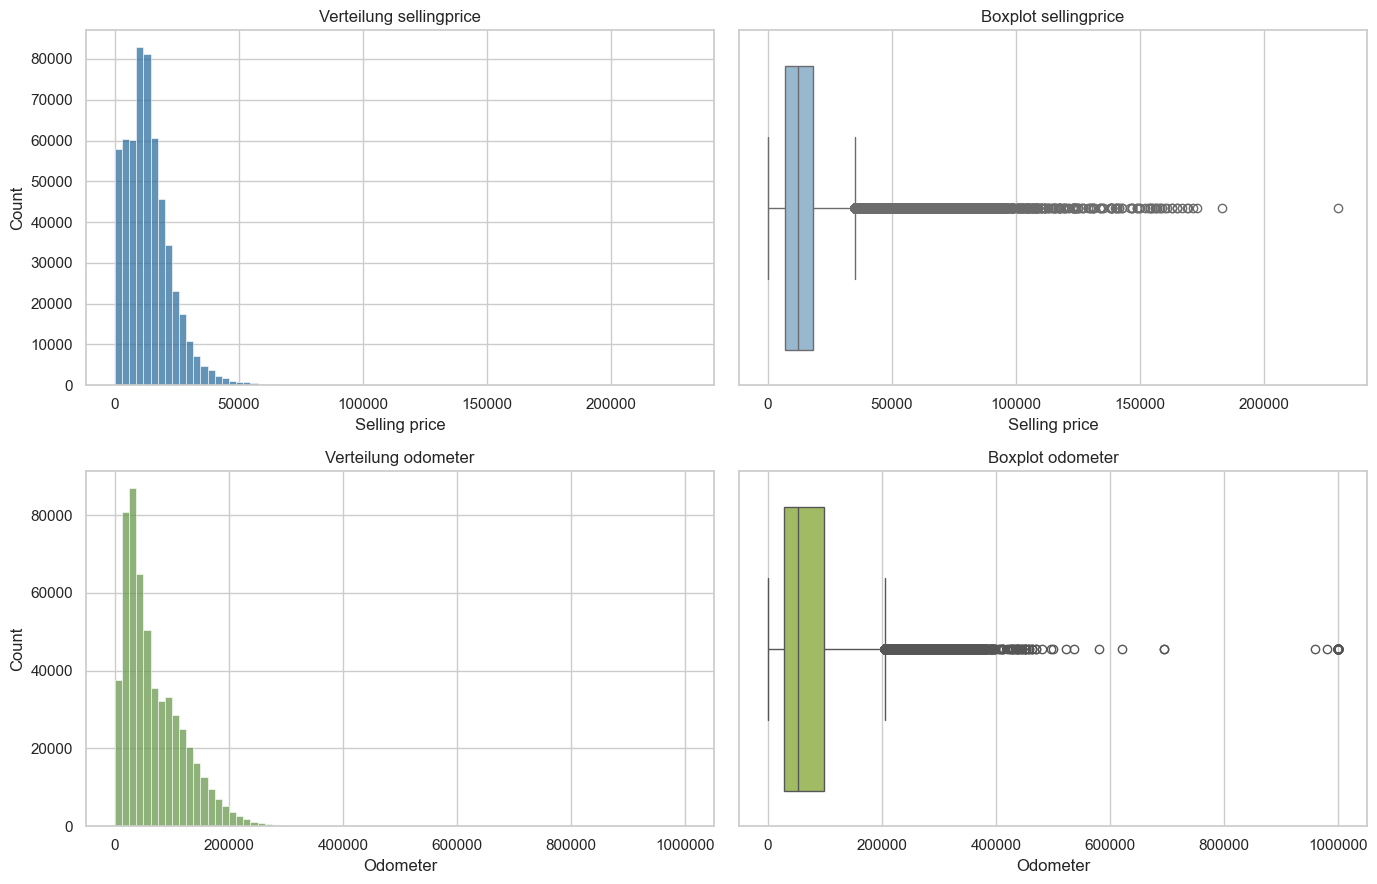

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(df["sellingprice"], bins=80, ax=axes[0, 0], color="#2f6f9f")
axes[0, 0].set_title("Verteilung sellingprice")
axes[0, 0].set_xlabel("Selling price")

sns.boxplot(x=df["sellingprice"], ax=axes[0, 1], color="#8fbad9")
axes[0, 1].set_title("Boxplot sellingprice")
axes[0, 1].set_xlabel("Selling price")

sns.histplot(df["odometer"].dropna(), bins=80, ax=axes[1, 0], color="#6a994e")
axes[1, 0].set_title("Verteilung odometer")
axes[1, 0].set_xlabel("Odometer")

sns.boxplot(x=df["odometer"].dropna(), ax=axes[1, 1], color="#a7c957")
axes[1, 1].set_title("Boxplot odometer")
axes[1, 1].set_xlabel("Odometer")

for ax in axes.ravel():
    ax.ticklabel_format(style="plain", axis="x")

plt.tight_layout()
plt.show()

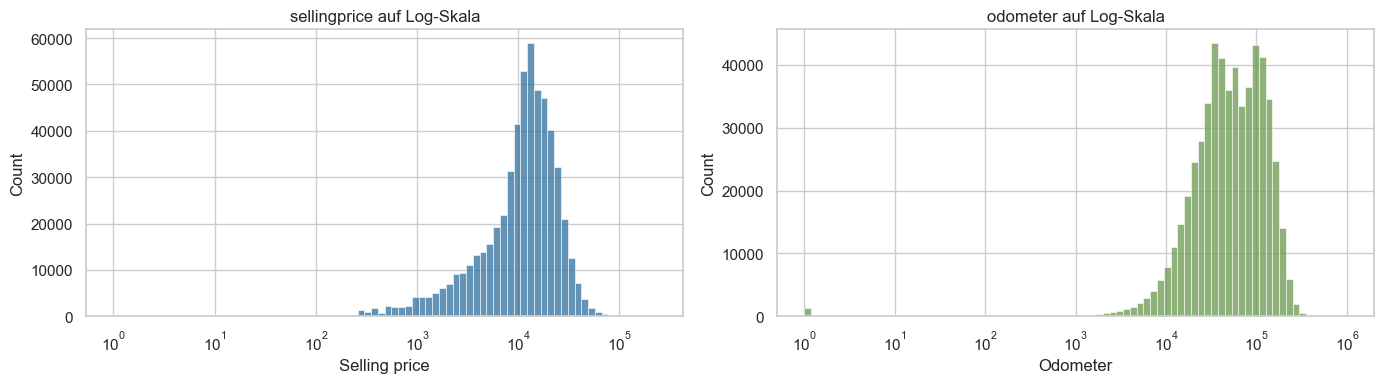

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df.loc[df["sellingprice"] > 0, "sellingprice"], bins=80, log_scale=True, ax=axes[0], color="#2f6f9f")
axes[0].set_title("sellingprice auf Log-Skala")
axes[0].set_xlabel("Selling price")

sns.histplot(df.loc[df["odometer"] > 0, "odometer"].dropna(), bins=80, log_scale=True, ax=axes[1], color="#6a994e")
axes[1].set_title("odometer auf Log-Skala")
axes[1].set_xlabel("Odometer")

plt.tight_layout()
plt.show()

In [8]:
checks = {
    "sellingprice <= 100": int((df["sellingprice"] <= 100).sum()),
    "sellingprice >= 100000": int((df["sellingprice"] >= 100000).sum()),
    "odometer <= 10": int((df["odometer"] <= 10).sum()),
    "odometer >= 300000": int((df["odometer"] >= 300000).sum()),
    "odometer missing": int(df["odometer"].isna().sum()),
    "transmission missing": int(df["transmission"].isna().sum()),
}

display(pd.Series(checks, name="count").to_frame())

display(
    df.loc[
        (df["sellingprice"] <= 100)
        | (df["sellingprice"] >= 100000)
        | (df["odometer"] >= 300000),
        ["year", "make", "model", "trim", "condition", "odometer", "mmr", "sellingprice", "saledate"]
    ].head(20)
)

,count
sellingprice <= 100,23
sellingprice >= 100000,167
odometer <= 10,1445
odometer >= 300000,744
odometer missing,94
transmission missing,65353


,year,make,model,trim,condition,odometer,mmr,sellingprice,saledate
275,2013,Hyundai,Elantra Coupe,GS,1.00,"999,999.00",8025,2500,Tue Jan 27 2015 04:00:00 GMT-0800 (PST)
1102,2012,Ferrari,California,Base,4.20,"10,902.00",149000,154000,Tue Dec 30 2014 12:30:00 GMT-0800 (PST)
2822,2009,Ford,Ranger,XL,2.00,"312,235.00",3050,2000,Wed Feb 11 2015 16:00:00 GMT-0800 (PST)
3760,2006,Chevrolet,Express Cargo,2500,2.00,"315,411.00",1600,2300,Tue Dec 16 2014 12:00:00 GMT-0800 (PST)
4155,2005,Dodge,Sprinter Cargo,2500 High Roof 140 WB,2.50,"316,490.00",2700,6500,Wed Dec 17 2014 12:30:00 GMT-0800 (PST)
4250,2005,Honda,CR-V,EX,NaN,"348,070.00",2275,3400,Wed Dec 17 2014 12:15:00 GMT-0800 (PST)
4339,2005,Lincoln,Town Car,Executive L Fleet,NaN,"381,875.00",2100,1100,Wed Dec 17 2014 12:30:00 GMT-0800 (PST)
4626,2003,Chevrolet,Silverado 1500,LS,2.00,"999,999.00",1425,700,Tue Dec 16 2014 13:00:00 GMT-0800 (PST)
4941,2001,Ford,F-250 Super Duty,XL,1.00,"311,164.00",925,700,Tue Dec 16 2014 12:00:00 GMT-0800 (PST)
4953,2001,Chevrolet,Silverado 1500HD,LS,2.80,"355,898.00",525,2600,Thu Jan 08 2015 12:00:00 GMT-0800 (PST)


## Auffälligkeiten

- `pd.read_csv("car_prices.csv")` scheitert ohne Zusatzparameter an fehlerhaften CSV-Zeilen. Das Notebook lädt den Datensatz daher mit `on_bad_lines="skip"` und weist die Anzahl übersprungener Zeilen aus.
- Der Datensatz ist groß genug für Modellierung: Nach dem robusten Laden bleiben über 558.000 Beobachtungen mit 16 Spalten übrig.
- `transmission` hat besonders viele fehlende Werte. Auch `body`, `condition`, `trim`, `model` und `make` enthalten Lücken und sollten vor dem Modelltraining bereinigt oder sinnvoll imputiert werden.
- `sellingprice` enthält sehr niedrige Werte bis 1 und sehr hohe Werte bis über 200.000. Diese Fälle sind potenzielle Ausreißer oder Spezialfahrzeuge.
- `odometer` reicht bis 999.999. Solche Werte sollten vor dem Training geprüft werden, weil sie echte Extremfälle, Eingabefehler oder Platzhalter sein können.
- `saledate` wird zunächst als Text geladen. Für Zeitreihen-Splits und saisonale Analysen sollte die Spalte später in ein echtes Datumsformat umgewandelt werden.